# Project Motivation

**Task** - the task is a to approximate a smooth non-linear function on a bounded 2D domain

Essentially this is a supervised regression task

As this project is for learning purposes rather pure practicality, we will be using a neural network even though there are more efficient methods of function interpolation.

### Why, can we use a neural network?
-- NEED TO ADD THAT WE CAN DO THIS USING UAT


Before we look at model architecture, training and so on, let's take a look at the data.

## Data Generation

For this project we will create synthetic data.
Here is the methodology :

We have some known smooth and non-linear function $f : [a,b]^2 \to \mathbb{R} , f(x,y)$   
where $a,b\in\mathbb{R}$

To generate the dataset, we take $n$ points $(x,y)\in[a,b]^2$
Then, we evaluate the function at these points and add some noise  
This gives us : $z_{i} = f(x_{i},y_{i}) + \epsilon_{i}\;\;1\leq i\leq n$ where $\epsilon_{i}\sim N(0,\sigma^2)\;\;i.d.d$  
This gives us the final dataset $\mathbf{D}=\{(x_{i} , y_{i} , z_{i}) \}_{i=1}^n$

This is implemented in the code below

So now we have our dataset $\mathbf{D}$, we can begin to think about the model and its implementation.

We need to : 

1) Choose a model
2) Choose a loss function
3) Choose weights that makes F a close approximation of the target function

#### (1) Choosing a model
We have already decided to use a neural network but we need to think about its structure.
For now, we will consider a simple Feed-Forward Network.

##### Feed-Forward Neural Network
<img src="fnn_diagram.png" alt="Feed-Forward Neural Network Diagram"/>

I have drawn this graph to show the general structure of an FNN.

An FNN simply consists of a set of "neurons" or "nodes" (taking inspiration from neurons in the brain).

These are modelled to be basic units of computation.
Typically, each neuron performs a weighted sum on its inputs and then adds some bias. To allow a network to capture more complex patterns, we then introduce non-linearity by applying a post activation function, giving a final output.
  
We then group a some of these neurons together, forming what we call a "layer".  
Thinking about a network in terms of its layers makes it easier when it comes to implementation.

We then take some these layers to form the network as shown above.  
The input layer just refers to the information we input into the network and does not actually perform any computation.  
The intermediate layers are called "hidden" because a user cannot directly interact with them. They perform most/all of the computation.  
Finally, we have the output layer which again doesn't perform any computation and is just the output of the network.  

How is everything connected?
Generally in an FNN, each neuron passes its output to every node in the next layer. This means that the network is "fully" connected.  
  
In different models, layers might not be sequentially arranged, the network might not be fully connected, and other modifications may be added. Additionally, we can make adjustments to model's architecture to improve the model's performance. 

How do we implement this/represent this mathematically?
  
*for convenience, i will explain everything in real numbers, but we can use different objects and so forth.*  
Representing a neuron:   
Suppose, we have $n$ inputs with the $i^{th}$ input, $x_i\in\mathbb{R}$ having weight $w_i\in\mathbb{R}$.  
We can then represent the weighted sum as $$\sum_{i=1}^{n}w_i x_i$$  
We can then add a bias term $b\in\mathbb{R}$, and then apply some activation function $\sigma:\mathbb{R}\to\mathbb{R}$
This gives us the output of a neuron $y\in\mathbb{R}$ as $$y=\sigma\big(\sum_{i=1}^n w_i x_i + b\big)$$


This is for one neuron, but what if we want to represent many neurons at once?  It would be quite messy to store and manage each neuron individually so we use linear algebra to help represent everything neatly.  
Notice that we can write the weighted sum for the $j^{th}$ node (with the $i^{th}$ input having a weight $w_ji$ for the $j^{th} node$) as $$\sum_{i=1}^n w_jix_i$$

This is actually the $i,j$ entry of some matrix multiplication $A\underline{x}$ where $A\in\mathbb{R}^{m \times n}$ and $\underline{x}\in\mathbb{R}^n$
# COMPLETE EXPLANATION

In [598]:
#Libraries needed

import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd

In [599]:
rand = np.random.default_rng(42)

#Defining the values we talked about
a = -100
b = 100
n = 1000

#Our target function f
def f(x,y):
    return x**2+y**2


xcoords = rand.uniform(low=a,high=b,size=(n,1))
ycoords = rand.uniform(low=a,high=b,size=(n,1))
noise = rand.normal(loc=0,scale=0.5,size=(n,1))
zcoords = f(xcoords,ycoords) + noise

dataset = np.concatenate((xcoords,ycoords,zcoords),axis=1)


#Simple scatter plot for visualisation
fig = px.scatter_3d(dataset,x=0,y=1,z=2)
fig.show()

In [600]:
def ReLu(x):
    return np.maximum(0,x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))
def MSE(labels,predictions):
    loss = np.sum((predictions - labels)**2)
    loss = loss/predictions.shape[0]
    return loss

def RMSE(labels,predictions):
    loss = MSE(labels,predictions)
    return np.sqrt(loss)


def MinMax(x,min,max,u=1,l=0):
    return (x-min)/(max-min) * (u-l) + l

def normalise(x,epsilon=1e-5):
    mean = np.mean(x)
    var = np.var(x)
    return (x-mean)/np.sqrt(var+epsilon) , mean , var , epsilon

In [601]:
#LayerWidths -> an arr storing the number of neurons in the (k+1)th layer (left to right)
#PostActFuncs -> an arr storing the post-act func of each layer
class network:
    def __init__(self, LayerWidths,PostActivationFuncs,NormalisationType = None):
        self.LayerNum = len(LayerWidths)-1
        self.LayerWidths = LayerWidths
        self.PostActivationFuncs = PostActivationFuncs
        self.layers = []
        self.LayerOutputs = []
        for i in range(1,self.LayerNum+1):
            if(i == self.LayerNum):
                layeri= layer(LayerWidths[i-1],LayerWidths[i],PostActivationFuncs[i],None)
            else:
                layeri= layer(LayerWidths[i-1],LayerWidths[i],PostActivationFuncs[i],NormalisationType)
            self.layers.append(layeri)


    def ForwardPass(self,input):
        self.LayerOutputs.clear()
        for i in range(self.LayerNum):
           input , LayerComputations = self.layers[i].compute(input)
           self.LayerOutputs.append(LayerComputations)

        return input

class layer:
    def __init__(self,InputWidth,width,PostActFunc,NormalisationType = None):
        sigma =  np.sqrt(2/(InputWidth+width))
        self.width = width
        self.PostActFunc = PostActFunc
        self.InputWidth = InputWidth
        self.weights = np.array(rand.normal(0,sigma, size=(width,InputWidth)))
        self.bias = np.array(rand.normal(0,sigma, size=(width,1)))
        #stochatistcally initialise a matrix

        #mini norm
        if NormalisationType == 'batch':
            self.gamma = np.random.rand()
            self.beta = np.random.rand()
            self.NormalisationType = 'batch'
        else:
            self.NormalisationType = None

    def compute(self,input):
        computations = {}
        LinearComputation = self.weights@input + self.bias
        computations["Linear"] = LinearComputation

        if self.NormalisationType == 'batch':

            LinearComputation , mean , var , epsilon = normalise(LinearComputation)
            computations["PostLinear"] = LinearComputation
            computations["mean"] = mean
            computations["var"] = var
            computations["epsilon"] = epsilon

            LinearComputation = self.gamma*LinearComputation+self.beta
            computations["Shifted"] = LinearComputation
        PostActComputation = self.PostActFunc(LinearComputation)
        computations["LayerOutput"] = PostActComputation
        return PostActComputation , computations

In [602]:
#formatting coords for input

TestTrainSplit = 0.5
batches = n//10
SplitIndex = int(TestTrainSplit*n)
TrainData  = dataset[:SplitIndex]
TestData = dataset[SplitIndex:]

TrainDataBatches = np.split(TrainData,batches)

In [603]:
#formed the netowrk
fnn = network([2,300,300,300,1],[lambda x : x,ReLu,ReLu,ReLu,lambda x : x],'batch')

In [604]:
def GradDesc(CurrVal,Gradient,LearningRate=0.001):
    return CurrVal - LearningRate*Gradient


In [ ]:
LossValues = []
IterNum = int(2e3)
LearningRate = 1e-3


MinInputs = list(map(lambda x : np.min(x[:,:-1],axis=0).reshape(2,1),TrainDataBatches))
MaxInputs = list(map(lambda x : np.max(x[:,:-1],axis=0).reshape(2,1),TrainDataBatches))
MinLabels = list(map(lambda x : np.min(x[:,-1],axis=0),TrainDataBatches))
MaxLabels = list(map(lambda x : np.max(x[:,-1],axis=0),TrainDataBatches))

for iteration in range(IterNum):

    indexes = np.arange(0,batches)
    np.random.shuffle(indexes)

    for BatchNum in indexes:
        CurrentBatch = TrainDataBatches[BatchNum]
        MinInput = MinInputs[BatchNum]
        MaxInput = MaxInputs[BatchNum]
        MinLabel = MinLabels[BatchNum]
        MaxLabel = MaxLabels[BatchNum]
        loss = 0
        predictions = 0

        W4 = fnn.layers[3].weights
        b4 = fnn.layers[3].bias



        W3 = fnn.layers[2].weights
        b3 = fnn.layers[2].bias
        beta3 = fnn.layers[2].beta
        gamma3 = fnn.layers[2].gamma


        W2 = fnn.layers[1].weights
        b2 = fnn.layers[1].bias
        beta2 = fnn.layers[1].beta
        gamma2 = fnn.layers[1].gamma


        W1 = fnn.layers[0].weights
        b1 = fnn.layers[0].bias
        beta1 = fnn.layers[0].beta
        gamma1 = fnn.layers[0].gamma

        dW4 = np.zeros((W4.shape))
        db4 = np.zeros((b4.shape))


        dW3 = np.zeros((W3.shape))
        db3 = np.zeros((b3.shape))
        dbeta3 = 0
        dgamma3 = 0

        dW2 = np.zeros((W2.shape))
        db2 = np.zeros((b2.shape))
        dbeta2 = 0
        dgamma2 = 0

        dW1 = np.zeros((W1.shape))
        db1 = np.zeros((b1.shape))
        dbeta1 = 0
        dgamma1 = 0

        NormalisedInputs = np.apply_along_axis(lambda x: MinMax(x.reshape(2,1),MinInput,MaxInput,l=-1),1,CurrentBatch[:,:-1])
        NormalisedLabels = MinMax(CurrentBatch[:,-1],MinLabel,MaxLabel,l=-1)
        N = CurrentBatch.shape[0]

        for i in range(N):
            x = NormalisedInputs[i,:]
            prediction = fnn.ForwardPass(x)
            loss += MSE(NormalisedLabels[i],prediction)

            dyhat = 2/N * (prediction - NormalisedLabels[i])

            #Layer 4
            a3 = fnn.LayerOutputs[2]["LayerOutput"]

            dW4 +=  dyhat * a3.T
            db4 += dyhat

            #Layer 3
            a2 = fnn.LayerOutputs[1]["LayerOutput"]
            mean3 =  fnn.LayerOutputs[2]["mean"]
            x3 = fnn.LayerOutputs[2]["Linear"]
            y3 = fnn.LayerOutputs[2]["PostLinear"]

            denom3 = 1 / np.sqrt(fnn.LayerOutputs[2]["var"] + fnn.LayerOutputs[2]["epsilon"])
            N3 = fnn.LayerOutputs[2]["LayerOutput"].shape[0]

            dydx3 = denom3 * (1-N3) - denom3 **2 * ( y3 @ (2/N3 * x3.T - 2 * N3 * mean3 ))

            delta3 = (W4.T @ dyhat) * (gamma3 * (dydx3 @ (a3 > 0).astype(float)))


            dW3 += delta3 @ a2.T
            db3 += delta3
            dbeta3 += np.sum(delta3)
            dgamma3 += np.sum(delta3 * y3)

            #Layer 2
            a1 = fnn.LayerOutputs[0]["LayerOutput"]
            mean2 =  fnn.LayerOutputs[1]["mean"]
            x2 = fnn.LayerOutputs[1]["Linear"]
            y2 = fnn.LayerOutputs[1]["PostLinear"]

            denom2 = 1 / np.sqrt(fnn.LayerOutputs[1]["var"] + fnn.LayerOutputs[1]["epsilon"])
            N2 = fnn.LayerOutputs[1]["LayerOutput"].shape[0]

            dydx2 = denom2 * (1-N2) - denom2 **2 * ( y2 @ (2/N2 * x2.T - 2 * N2 * mean2 ))

            delta2 = (W3.T @ delta3) * (gamma2 * (dydx2 @ (a2 > 0).astype(float)))


            dW2 += delta2 @ a1.T
            db2 += delta2
            dbeta2 += np.sum(delta2)
            dgamma2 += np.sum(delta2 * y2)



            #Layer 1
            mean1 =  fnn.LayerOutputs[0]["mean"]
            x1 = fnn.LayerOutputs[0]["Linear"]
            y1 = fnn.LayerOutputs[0]["PostLinear"]

            denom1 = 1 / np.sqrt(fnn.LayerOutputs[0]["var"] + fnn.LayerOutputs[0]["epsilon"])
            N1 = fnn.LayerOutputs[0]["LayerOutput"].shape[0]

            dydx1 = denom1 * (1-N1) - denom1 **2 * ( y1 @ (2/N1 * x1.T - 2 * N1 * mean1 ))

            delta1 = (W2.T @ delta2) * (gamma1 * (dydx1 @ (a1 > 0).astype(float)))

            dW1 += delta1 @ x.T
            db1 += delta1
            dbeta1 += np.sum(delta1)
            dgamma1 += np.sum(delta1 * y1)


        fnn.layers[3].bias = GradDesc(b4,db4,LearningRate)
        fnn.layers[3].weights = GradDesc(W4,dW4,LearningRate)


        fnn.layers[2].bias = GradDesc(b3,db3,LearningRate)
        fnn.layers[2].weights = GradDesc(W3,dW3,LearningRate)

        fnn.layers[2].beta = GradDesc(beta3,dbeta3,LearningRate)
        fnn.layers[2].gamma = GradDesc(gamma3,dgamma3,LearningRate)

        fnn.layers[1].bias = GradDesc(b2,db2,LearningRate)
        fnn.layers[1].weights = GradDesc(W2,dW2,LearningRate)

        fnn.layers[1].beta = GradDesc(beta2,dbeta2,LearningRate)
        fnn.layers[1].gamma = GradDesc(gamma2,dgamma2,LearningRate)

        fnn.layers[0].bias = GradDesc(b1,db1,LearningRate)
        fnn.layers[0].weights = GradDesc(W1,dW1,LearningRate)

        fnn.layers[0].beta = GradDesc(beta1,dbeta1,LearningRate)
        fnn.layers[0].gamma = GradDesc(gamma1,dgamma1,LearningRate)
        LossValues.append(np.sqrt(loss))

    print(f"epoch : {iteration}, loss : {loss} ")





epoch : 0, loss : 3.7975857381452442 
epoch : 1, loss : 2.2392519711149075 
epoch : 2, loss : 3.1491456515664984 
epoch : 3, loss : 3.726912121391399 
epoch : 4, loss : 4.153021931262336 
epoch : 5, loss : 3.0741041927570296 
epoch : 6, loss : 2.6081820036047345 
epoch : 7, loss : 3.742502224792903 
epoch : 8, loss : 3.4430642518750076 
epoch : 9, loss : 2.6754210954470565 
epoch : 10, loss : 3.6689395231060713 
epoch : 11, loss : 2.299705563254677 
epoch : 12, loss : 3.461252064310398 
epoch : 13, loss : 3.1334253576177007 
epoch : 14, loss : 3.6828989958861005 
epoch : 15, loss : 4.216850805258313 
epoch : 16, loss : 2.6542589102762717 
epoch : 17, loss : 3.891910330383331 
epoch : 18, loss : 3.466484998085802 
epoch : 19, loss : 2.958256192016342 
epoch : 20, loss : 3.775514302135439 
epoch : 21, loss : 2.8569382797068767 
epoch : 22, loss : 2.64195038428009 
epoch : 23, loss : 2.8871895521156397 
epoch : 24, loss : 3.798989299146943 
epoch : 25, loss : 2.409513314195038 
epoch : 26

KeyboardInterrupt: 

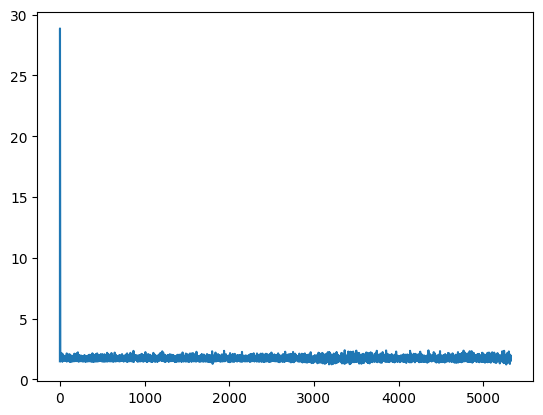

In [606]:
plt.plot([i for i in range(len(LossValues))],LossValues)
plt.show()

In [607]:
def apply_feed(x):
    x = x.reshape(2,1)
    normalised = MinMax(x,np.min(x,0),np.max(x,0))
    return fnn.ForwardPass(normalised)


TestPredictions = np.apply_along_axis(apply_feed,1,TestData[:,:-1])
print(TestPredictions.shape)
smallest = np.min(TestData[:,-1])
biggest = np.max(TestData[:,-1])
TestNormal = MinMax(TestData[:,-1],smallest,biggest)
RMSE(TestNormal,TestPredictions)

(500, 1, 1)


np.float64(14.793982099095578)